# 05 · Schedule refrigeration across operating periods

Share one chiller investment across two periods while electricity price and cooling demand change.

Use Python 3.14.2 or newer. In a terminal, run `python -m pip install "OpenUtility[notebook]>=0.1.2"`, then `python -m jupyterlab`. Select that environment's Python kernel and choose **Restart Kernel and Run All Cells**. No repository checkout, external files, credentials, or commercial solver is needed; HiGHS comes with OpenUtility. All data and prices below are synthetic, in arbitrary currency units (CU).

In [1]:
from dataclasses import asdict
from importlib.metadata import version
import math
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import OpenUtility as ou
from IPython.display import display

print(f"OpenUtility {version('OpenUtility')}")
plt.rcParams.update(
    {"figure.figsize": (7, 4), "axes.spines.top": False, "axes.spines.right": False}
)
solve = ou.pyomo_utility_system_solver("appsi_highs")

OpenUtility 0.1.2


## Cooling COP and condenser rejection

At −5°C evaporator and 35°C condenser temperatures, a cooling COP of 4 means 100 kW cooling consumes 25 kW electricity and rejects 125 kW heat. This synthetic map has half-load and full-load points. Heat rejection has zero unit cost but a finite 200 kW capacity.

In [2]:
# The current schema requires a steam level, even for electricity/HPR examples.
# This zero-duty placeholder contributes no heat, steam, or cost.
level = ou.SteamLevelCandidate(
    name="MP_100",
    steam_main="MP",
    temperature=100.0,
    source_heat_available=0.0,
    sink_heat_demand=0.0,
    generation_enthalpy_delta=1.0,
    use_enthalpy_delta=1.0,
)

performance = ou.HprPerformanceMap(
    schema_version="1.0",
    map_id="tutorial-map",
    mode="refrigeration",
    units={
        "source_temperature": "degC",
        "sink_temperature": "degC",
        "q_source": "kW",
        "q_sink": "kW",
        "electric_power": "kW",
    },
    reference_capacity=100.0,
    reference_capacity_basis="q_source",
    interpolation_topology="ordered_part_load_curve",
    thermodynamic_backend="synthetic",
    model_id="constant-cop",
    provenance={
        "source": "OpenUtility public tutorial; synthetic energy-balanced data"
    },
    cop_convention="cooling",
    points=tuple(
        ou.HprPerformancePoint(
            name=f"load-{fraction}",
            curve_id="fixed-temperatures",
            source_temperature=-5.0,
            sink_temperature=35.0,
            load_fraction=fraction,
            q_source=100.0 * fraction,
            q_sink=125.0 * fraction,
            electric_power=25.0 * fraction,
        )
        for fraction in (0.5, 1.0)
    ),
)
display(pd.DataFrame([asdict(point) for point in performance.points]))

,name,curve_id,source_temperature,sink_temperature,load_fraction,q_source,q_sink,electric_power,cop
0,load-0.5,fixed-temperatures,-5.0,35.0,0.5,50.0,62.5,12.5,None
1,load-1.0,fixed-temperatures,-5.0,35.0,1.0,100.0,125.0,25.0,None


## Two periods, one investment

Both periods last 2,000 h. Night cooling is 50 kW at 0.10 CU/kWh electricity; peak cooling is 100 kW at 0.30 CU/kWh. Backup cooling costs 0.06 CU/kWh. Annualized chiller investment is 2,000 CU/year. Period-weighted costs already account for time; leave static operating hours at their default.

,Chiller cooling (kW),Backup cooling (kW),Electricity (kW),Rejected heat (kW)
Period,,,,
night,50.0,0.0,12.5,62.5
peak,0.0,100.0,0.0,0.0


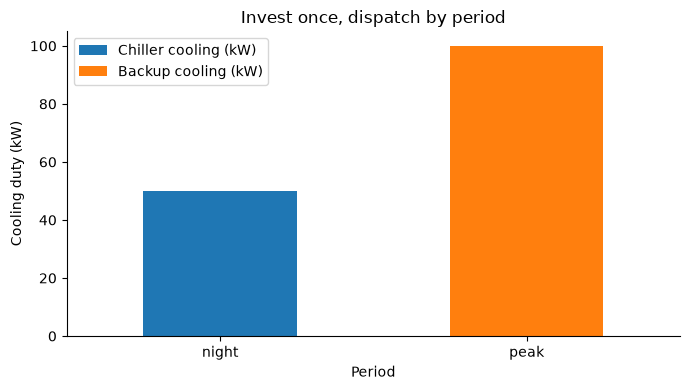

In [3]:
periods = tuple(
    ou.OperatingPeriod(
        name=name,
        hours=2000.0,
        electricity_import_unit_cost=tariff,
        cooling_demand={"cold": demand},
        rejection_capacity={"reject": 200.0},
    )
    for name, tariff, demand in (("night", 0.10, 50.0), ("peak", 0.30, 100.0))
)
data = ou.UtilitySystemModelData(
    steam_mains=("MP",),
    steam_levels=(level,),
    power_demand=0.0,
    grid_import_limit=0.0,
    grid_export_limit=0.0,
    periods=periods,
    thermal_nodes=(
        ou.ThermalNode("cold", -5.0, "cooling", cooling_unit_cost=0.06),
        ou.ThermalNode("reject", 35.0, "rejection"),
    ),
    hpr_performance_maps=(performance,),
    hpr_candidates=(
        ou.HprCandidate(
            name="chiller",
            mode="refrigeration",
            map_id="tutorial-map",
            source_node="cold",
            rejection_node="reject",
            fixed_capacity=100.0,
        ),
    ),
    equipment_costs=(
        ou.EquipmentCost(
            name="Chiller investment",
            equipment_type="hpr",
            equipment_name="chiller",
            annualization_factor=0.1,
            installation_factor=1.0,
            variable_capital_cost=0.0,
            fixed_capital_cost=20000.0,
        ),
    ),
)
model = ou.build_utility_system_model(data)
status = solve(model)
assert status.termination_condition == "optimal", status
rows = []
for period in periods:
    cooling = pyo.value(model.hpr_q_source["chiller", period.name])
    power = pyo.value(model.hpr_power["chiller", period.name])
    rejected = pyo.value(model.hpr_rejected_heat["chiller", period.name])
    backup = pyo.value(model.node_external_cooling[period.name, "cold"])
    assert math.isclose(cooling + backup, period.cooling_demand["cold"], abs_tol=1e-6)
    assert math.isclose(rejected, cooling + power, abs_tol=1e-6)
    rows.append(
        {
            "Period": period.name,
            "Chiller cooling (kW)": cooling,
            "Backup cooling (kW)": backup,
            "Electricity (kW)": power,
            "Rejected heat (kW)": rejected,
        }
    )
dispatch = pd.DataFrame(rows).set_index("Period")
assert pyo.value(model.hpr_selected["chiller"]) > 0.5
assert math.isclose(dispatch.loc["night", "Chiller cooling (kW)"], 50.0, abs_tol=1e-6)
assert math.isclose(dispatch.loc["peak", "Chiller cooling (kW)"], 0.0, abs_tol=1e-6)
assert math.isclose(pyo.value(model.total_annualized_cost), 16500.0, abs_tol=1e-6)
display(dispatch)
ax = dispatch[["Chiller cooling (kW)", "Backup cooling (kW)"]].plot.bar(
    stacked=True, rot=0
)
ax.set(ylabel="Cooling duty (kW)", title="Invest once, dispatch by period")
plt.tight_layout()
plt.show()

## Interpret the result

Night electricity costs 2,500 CU/year, peak backup cooling costs 12,000 CU/year, and capital costs 2,000 CU/year: **16,500 CU/year** versus 18,000 for backup alone. Investing does not require running at every tariff. Try reducing peak electricity to 0.20 CU/kWh; the chiller should then run in both periods.